# Cloning the Repo

In [1]:
#!git clone https://github.com/Tahoni01/Continual-hate-speech-detection.git
%cd Continual-hate-speech-detection

[WinError 2] Impossibile trovare il file specificato: 'Continual-hate-speech-detection'
c:\Uni\Continual-hate-speech-detection


# Install all the necessary library

In [2]:
%pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Cella 1
import torch
print(torch.__version__)           # 2.6.0+cu128
print(torch.cuda.is_available())   # True
print(torch.cuda.get_device_properties(0).major)  # 12

2.7.0+cu128
True
12


In [4]:
# Cella 2 — solo se cella 1 passa
from transformers import AutoTokenizer

c:\Uni\Continual-hate-speech-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Cella 3 — solo se cella 2 passa
from model_utils.model_builder import CustomClassifier

In [6]:
from dataset.df_loader import getdf_davidson, getdf_hatexplain
from dataset.stream_generator import create_continual_stream, create_stream, online_stream#from transformers import (AutoTokenizer, AutoConfig)
from model_utils.trainer import ContinualTrainer

## Check if a GPU is avaible

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

DEVICE: cuda


### Getting the datasets

In [8]:
print("Loading datasets...")

train_dv, val_dv = getdf_davidson()
train_hx, val_hx = getdf_hatexplain()

print(f"Davidson   — train: {train_dv.shape} | val: {val_dv.shape}")
print(f"HateXplain — train: {train_hx.shape} | val: {val_hx.shape}")

Loading datasets...
Davidson   — train: 19420 | val: 4855
HateXplain — train: 16115 | val: 4029
Davidson   — train: (19420, 3) | val: (4855, 3)
HateXplain — train: (16115, 3) | val: (4029, 3)


### Creating the datastream

In [9]:
# stream di train per il continual learning
stream_davidson   = create_continual_stream([train_dv], batch_size=10)
stream_hatexplain = create_continual_stream([train_hx], batch_size=10)
full_stream       = stream_davidson + stream_hatexplain

# stream di val per evaluation (no shuffle)
val_stream_dv = create_stream(val_dv, batch_size=10, shuffle=False)
val_stream_hx = create_stream(val_hx, batch_size=10, shuffle=False)

### Creating the tokenizer and the pretrained model + custom head

In [10]:
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilroberta-base")

model = CustomClassifier(
    model_name="distilbert/distilroberta-base",
    num_labels=3,
    )

model.to(device)

CustomClassifier(
  (backbone): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm):

## Training Session

In [11]:
import matplotlib.pyplot as plt
from strategy.replay import ReplayStrategy
from strategy.distillation import DistillationStrategy
from strategy.ewc import EWCStrategy
from utils.metrics import compute_accuracy, compute_f1
from utils.plot_utils import (
    plot_loss,
    plot_batch_metrics,
    plot_conf_matrix,
    plot_classwise_accuracy,
    plot_label_distribution,
    plot_strategy_comparison,
    plot_forgetting
)

Config: BATCH_SIZE=32, BUFFER_SIZE=750, LR=2e-05
=== Task 1: HateXplain ===


100%|██████████| 1612/1612 [00:33<00:00, 48.74it/s]


HateXplain val (pre) — Acc: 0.6570 | F1: 0.5868
[EWC] Fisher aggiornata su 1612 batch.

=== Task 2: Davidson ===


100%|██████████| 1942/1942 [00:42<00:00, 45.44it/s]


[EWC] Fisher aggiornata su 1942 batch.
Davidson val     — Acc: 0.9075 | F1: 0.6821

=== Eval forgetting ===
HateXplain val (post) — Acc: 0.5041 | F1: 0.4928
Forgetting F1         : +0.0940


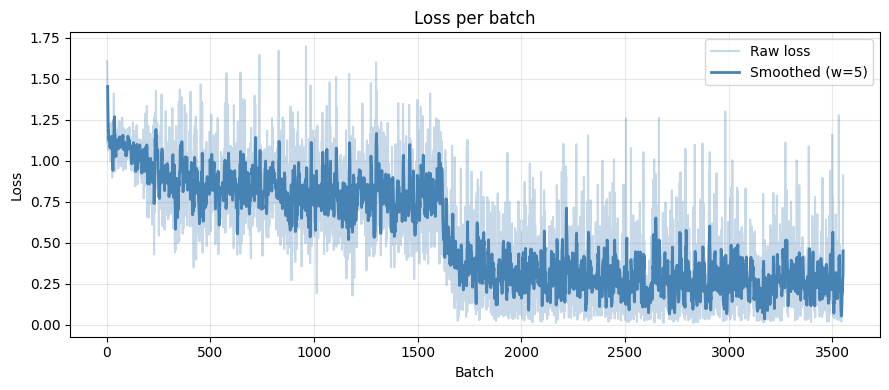

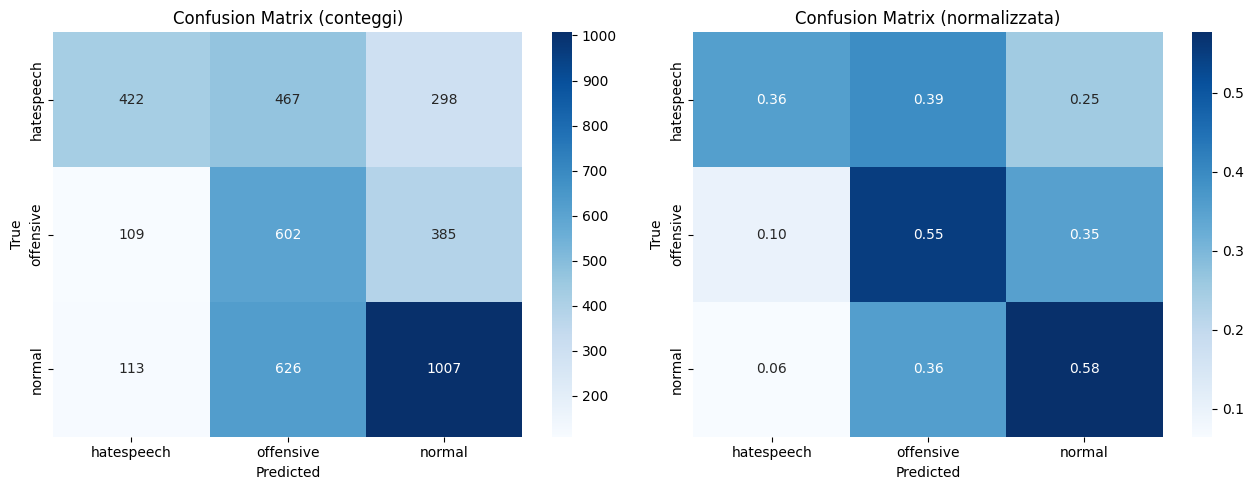

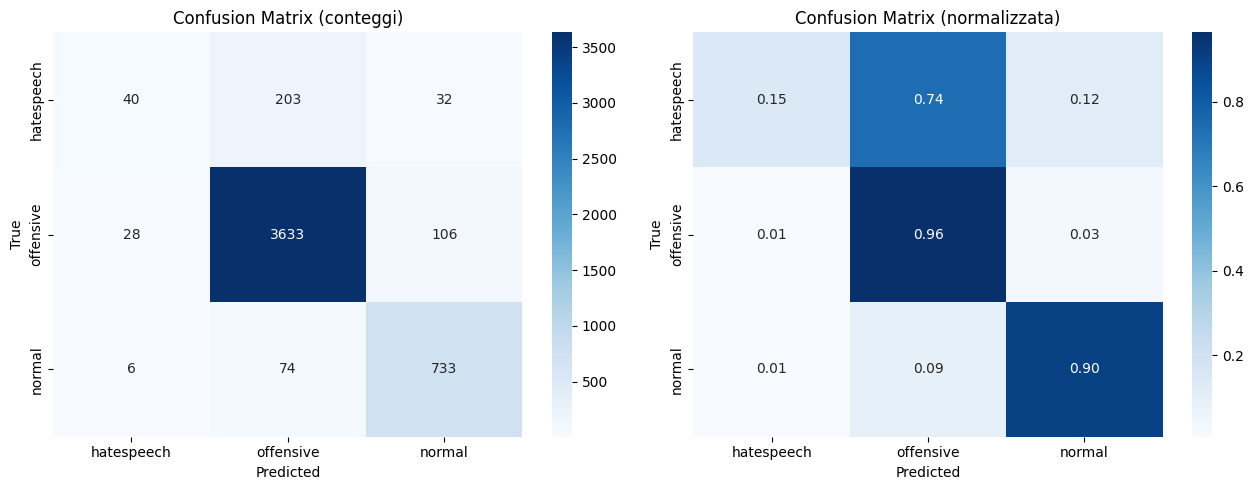

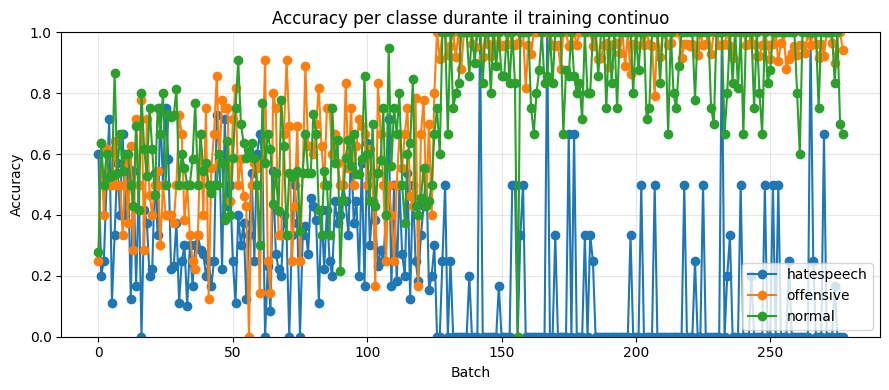

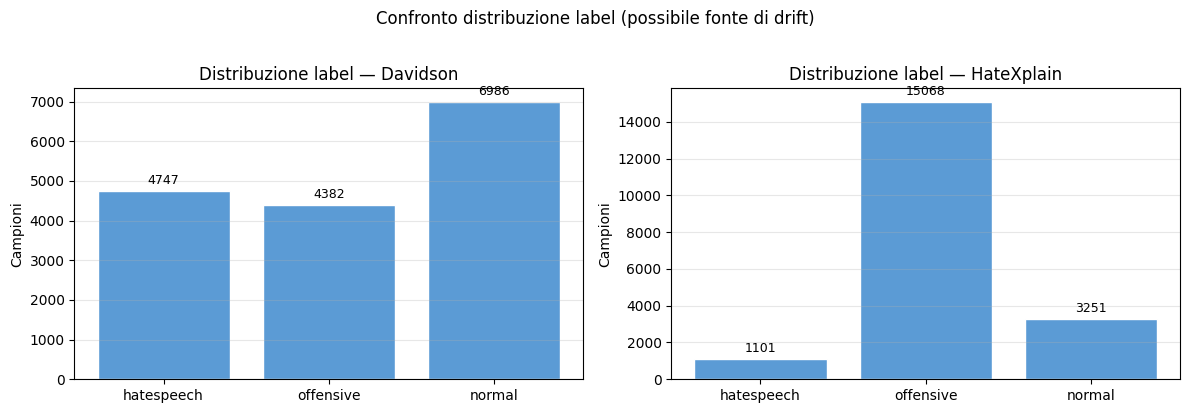

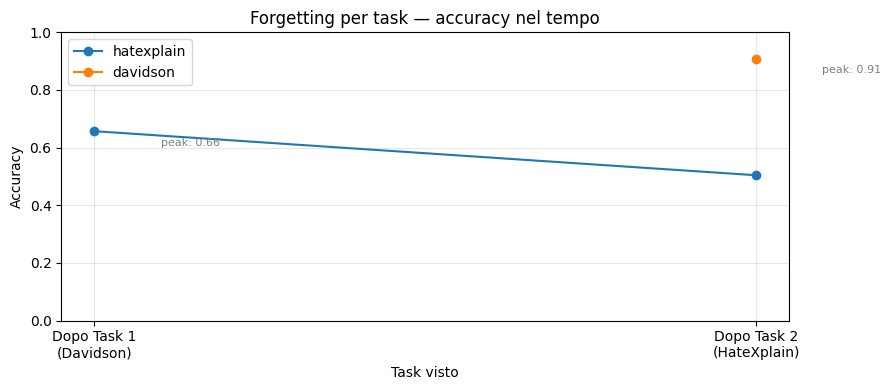

In [12]:
# ─── CONFIG ──────────────────────────────────────────────────────────────────

BATCH_SIZE = 32
BUFFER_SIZE = 750
LR = 2e-5

print(f"Config: BATCH_SIZE={BATCH_SIZE}, BUFFER_SIZE={BUFFER_SIZE}, LR={LR}")
label_map = {"hatespeech": 0, "offensive": 1, "normal": 2}

# ─── STRATEGY ────────────────────────────────────────────────────────────────

#strategy = ReplayStrategy(buffer_size=BUFFER_SIZE)
strategy = EWCStrategy(lambda_=0.4)
#strategy = DistillationStrategy(alpha=0.5, temperature=2.0)

# ─── TRAINER ─────────────────────────────────────────────────────────────────

trainer = ContinualTrainer(model=model, tokenizer=tokenizer, device=device, lr=LR)
trainer.add_strategy(strategy)

"""
# ─── TRAIN TASK 1 — Davidson ─────────────────────────────────────────────────

print("=== Task 1: Davidson ===")
losses_dv, preds_dv, labels_dv = trainer.train_continual(stream_davidson, label_map)

# eval su val set dopo task 1 — baseline pre-forgetting
preds_dv_pre, labels_dv_pre = trainer.evaluate(val_stream_dv, label_map)
acc_dv_pre = compute_accuracy(preds_dv_pre, labels_dv_pre)
f1_dv_pre  = compute_f1(preds_dv_pre, labels_dv_pre)
print(f"Davidson val (pre) — Acc: {acc_dv_pre:.4f} | F1: {f1_dv_pre:.4f}")

trainer.on_task_end(stream_davidson, label_map)

# ─── TRAIN TASK 2 — HateXplain ───────────────────────────────────────────────

print("\n=== Task 2: HateXplain ===")
losses_hx, preds_hx, labels_hx = trainer.train_continual(stream_hatexplain, label_map)
trainer.on_task_end(stream_hatexplain, label_map)

preds_hx_post, labels_hx_post = trainer.evaluate(val_stream_hx, label_map)
acc_hx_post = compute_accuracy(preds_hx_post, labels_hx_post)
f1_hx_post  = compute_f1(preds_hx_post, labels_hx_post)
print(f"HateXplain val     — Acc: {acc_hx_post:.4f} | F1: {f1_hx_post:.4f}")

# ─── EVAL FORGETTING ─────────────────────────────────────────────────────────

print("\n=== Eval forgetting ===")
preds_dv_post, labels_dv_post = trainer.evaluate(val_stream_dv, label_map)
acc_dv_post = compute_accuracy(preds_dv_post, labels_dv_post)
f1_dv_post  = compute_f1(preds_dv_post, labels_dv_post)
print(f"Davidson val (post) — Acc: {acc_dv_post:.4f} | F1: {f1_dv_post:.4f}")
print(f"Forgetting F1      : {f1_dv_pre - f1_dv_post:+.4f}")

# ─── PLOT ────────────────────────────────────────────────────────────────────

plot_loss(losses_dv + losses_hx)
plot_conf_matrix(preds_dv_post, labels_dv_post, label_map)
plot_conf_matrix(preds_hx_post, labels_hx_post, label_map)
plot_classwise_accuracy(
    torch.cat([preds_dv_post, preds_hx_post]),
    torch.cat([labels_dv_post, labels_hx_post]),
    label_map, batch_size=BATCH_SIZE
)
plot_label_distribution(train_dv, train_hx, label_map)
plot_forgetting(
    {"davidson":   [acc_dv_pre, acc_dv_post],
     "hatexplain": [None,       acc_hx_post]},
    label_map
)
"""

# ─── TRAIN TASK 1 — HateXplain ───────────────────────────────────────────────

print("=== Task 1: HateXplain ===")
losses_hx, preds_hx, labels_hx = trainer.train_continual(stream_hatexplain, label_map)

# eval su val set dopo task 1
preds_hx_pre, labels_hx_pre = trainer.evaluate(val_stream_hx, label_map)
acc_hx_pre = compute_accuracy(preds_hx_pre, labels_hx_pre)
f1_hx_pre  = compute_f1(preds_hx_pre, labels_hx_pre)
print(f"HateXplain val (pre) — Acc: {acc_hx_pre:.4f} | F1: {f1_hx_pre:.4f}")

trainer.on_task_end(stream_hatexplain, label_map)

# ─── TRAIN TASK 2 — Davidson ───────────────────────────────────────────────

print("\n=== Task 2: Davidson ===")
losses_dv, preds_dv, labels_dv = trainer.train_continual(stream_davidson, label_map)
trainer.on_task_end(stream_davidson, label_map)

preds_dv_post, labels_dv_post = trainer.evaluate(val_stream_dv, label_map)
acc_dv_post = compute_accuracy(preds_dv_post, labels_dv_post)
f1_dv_post  = compute_f1(preds_dv_post, labels_dv_post)
print(f"Davidson val     — Acc: {acc_dv_post:.4f} | F1: {f1_dv_post:.4f}")

# ─── EVAL FORGETTING ─────────────────────────────────────────────────────────

print("\n=== Eval forgetting ===")
preds_hx_post, labels_hx_post = trainer.evaluate(val_stream_hx, label_map)
acc_hx_post = compute_accuracy(preds_hx_post, labels_hx_post)
f1_hx_post  = compute_f1(preds_hx_post, labels_hx_post)

print(f"HateXplain val (post) — Acc: {acc_hx_post:.4f} | F1: {f1_hx_post:.4f}")
print(f"Forgetting F1         : {f1_hx_pre - f1_hx_post:+.4f}")

# ─── PLOT ────────────────────────────────────────────────────────────────────

# loss in ordine corretto (Task 1 → Task 2)
plot_loss(losses_hx + losses_dv)

# confusion matrix (post training per entrambi i task)
plot_conf_matrix(preds_hx_post, labels_hx_post, label_map)
plot_conf_matrix(preds_dv_post, labels_dv_post, label_map)

# classwise accuracy su entrambi i task finali
plot_classwise_accuracy(
    torch.cat([preds_hx_post, preds_dv_post]),
    torch.cat([labels_hx_post, labels_dv_post]),
    label_map,
    batch_size=BATCH_SIZE
)

# label distribution (non dipende dall’ordine, ma meglio coerente)
plot_label_distribution(train_hx, train_dv, label_map)

# forgetting (ATTENZIONE: invertito!)
plot_forgetting(
    {
        "hatexplain": [acc_hx_pre, acc_hx_post],
        "davidson":   [None,       acc_dv_post]
    },
    label_map
)

In [13]:
SAVE_DIR = "./models"

torch.save({
    "model_state_dict": model.state_dict(),
    "model_name": "distilbert/distilroberta-base",
    "label_map": label_map,
    "strategy": strategy.__class__.__name__,
    "batch_size": BATCH_SIZE,
    "buffer_size": BUFFER_SIZE,
    "lr": LR
}, f"{SAVE_DIR}/model.pt")

tokenizer.save_pretrained(SAVE_DIR)

print("Salvataggio completato")

Salvataggio completato


In [14]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("./models/model.pt", map_location=DEVICE)
label_map = checkpoint["label_map"]

id2label = {v: k for k, v in label_map.items()}

loaded_tokenizer = AutoTokenizer.from_pretrained("./models")

loaded_model = CustomClassifier(
    model_name="distilbert/distilroberta-base",
    num_labels=len(label_map)
)

loaded_model.load_state_dict(checkpoint["model_state_dict"])

loaded_model.to(DEVICE)
loaded_model.eval()

print("Modello ricaricato correttamente")

Modello ricaricato correttamente


In [16]:
from types import SimpleNamespace
import torch.nn.functional as F

def predict_text(text, model, tokenizer, id2label, device):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=-1)
        pred_id = torch.argmax(probs, dim=1).item()

    return SimpleNamespace(
        text=text,
        prediction=id2label[pred_id],
        confidence=probs[0][pred_id].item(),
        all_probs={
            id2label[i]: round(probs[0][i].item(), 4)
            for i in range(len(id2label))
        }
    )

In [23]:
result = predict_text("this fucking moron", loaded_model, loaded_tokenizer, id2label, device)

print(result.prediction)
print(result.confidence)

offensive
0.846825122833252
